In [7]:
from pydub import AudioSegment
import os

# Path to the audio folder
audio_folder = '../A_DataCollection/mp3'

# Dictionary to store loaded audio files
audio_files = {}

# Check if the folder exists
if os.path.exists(audio_folder):
    # Iterate through all audio files in the folder
    for filename in os.listdir(audio_folder):
        if filename.endswith(('.wav', '.mp3', '.ogg')):
            audio_path = os.path.join(audio_folder, filename)
            try:
                audio = AudioSegment.from_file(audio_path)
                audio_files[filename] = audio
            except Exception as e:
                print(f"Failed to load {filename}: {e}")
else:
    print("The 'audio' folder does not exist.")

# Print the names of successfully loaded audio files
print(list(audio_files.keys()))


['AD_Andorra.mp3', 'AE_United_Arab_Emirates.mp3', 'AF_Afghanistan.mp3', 'AG_Antigua_and_Barbuda.mp3', 'AI_Anguilla.mp3', 'AL_Albania.mp3', 'AM_Armenia.mp3', 'AO_Angola.mp3', 'AR_Argentina.mp3', 'AT_Austria.mp3', 'AU_Australia.mp3', 'AW_Aruba.mp3', 'AX_Åland_Islands.mp3', 'AZ_Azerbaijan.mp3', 'BB_Barbados.mp3', 'BD_Bangladesh.mp3', 'BF_Burkina_Faso.mp3', 'BG_Bulgaria.mp3', 'BH_Bahrain.mp3', 'BJ_Benin.mp3', 'BL_Saint_Barthélemy.mp3', 'BM_Bermuda.mp3', 'BN_Brunei_Darussalam.mp3', 'BO_Bolivia,_Plurinational_State_of.mp3', 'BR_Brazil.mp3', 'BS_Bahamas.mp3', 'BT_Bhutan.mp3', 'BW_Botswana.mp3', 'BY_Belarus.mp3', 'BZ_Belize.mp3', 'CA_Canada.mp3', 'CD_Congo,_the_Democratic_Republic_of_the.mp3', 'CF_Central_African_Republic.mp3', 'CG_Republic_of_the_Congo.mp3', "CI_Côte_d'Ivoire.mp3", 'CK_Cook_Islands.mp3', 'CL_Chile.mp3', 'CM_Cameroon.mp3', "CN_China_(People's_Republic_of_China).mp3", 'CO_Colombia.mp3', 'CR_Costa_Rica.mp3', 'CU_Cuba.mp3', 'CV_Cape_Verde.mp3', 'CW_Curaçao.mp3', 'CZ_Czech_Republi

## EDA

In [8]:
# Perform EDA on the loaded audio files
eda_results = {}
for filename, audio in audio_files.items():
    eda_results[filename] = {
        'duration_seconds': len(audio) / 1000,  # Duration in seconds
        'channels': audio.channels,            # Number of channels
        'frame_rate': audio.frame_rate,        # Frame rate (sampling rate)
        'sample_width': audio.sample_width     # Sample width in bytes
    }

print(eda_results)


{'AD_Andorra.mp3': {'duration_seconds': 156.97, 'channels': 2, 'frame_rate': 44100, 'sample_width': 2}, 'AE_United_Arab_Emirates.mp3': {'duration_seconds': 48.457, 'channels': 2, 'frame_rate': 44100, 'sample_width': 2}, 'AF_Afghanistan.mp3': {'duration_seconds': 74.005, 'channels': 2, 'frame_rate': 44100, 'sample_width': 2}, 'AG_Antigua_and_Barbuda.mp3': {'duration_seconds': 60.891, 'channels': 2, 'frame_rate': 44100, 'sample_width': 2}, 'AI_Anguilla.mp3': {'duration_seconds': 78.289, 'channels': 2, 'frame_rate': 44100, 'sample_width': 2}, 'AL_Albania.mp3': {'duration_seconds': 65.959, 'channels': 2, 'frame_rate': 44100, 'sample_width': 2}, 'AM_Armenia.mp3': {'duration_seconds': 29.649, 'channels': 2, 'frame_rate': 44100, 'sample_width': 2}, 'AO_Angola.mp3': {'duration_seconds': 81.92, 'channels': 2, 'frame_rate': 44100, 'sample_width': 2}, 'AR_Argentina.mp3': {'duration_seconds': 213.342, 'channels': 2, 'frame_rate': 44100, 'sample_width': 2}, 'AT_Austria.mp3': {'duration_seconds': 89

##  Plotting

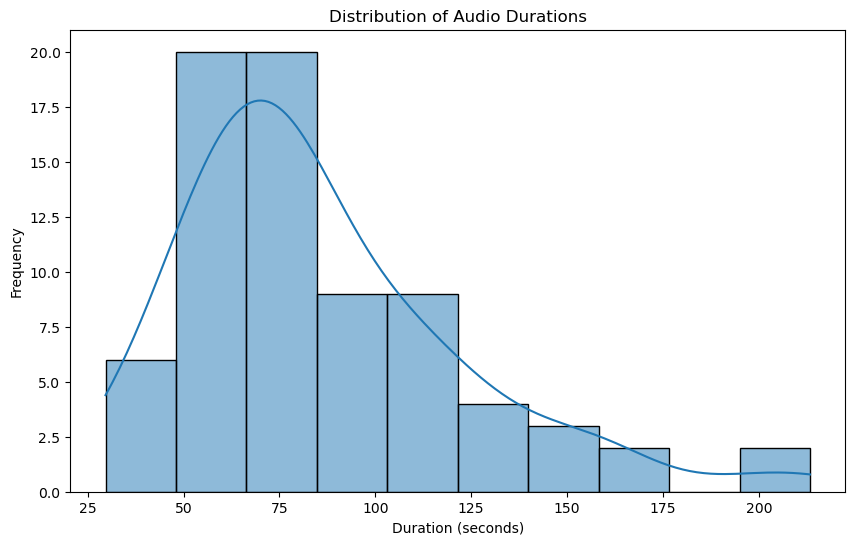

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract features into separate lists for plotting
durations = [data['duration_seconds'] for data in eda_results.values()]
channels = [data['channels'] for data in eda_results.values()]
frame_rates = [data['frame_rate'] for data in eda_results.values()]
sample_widths = [data['sample_width'] for data in eda_results.values()]

# Plot durations
plt.figure(figsize=(10, 6))
sns.histplot(durations, kde=True)
plt.title('Distribution of Audio Durations')
plt.xlabel('Duration (seconds)')
plt.ylabel('Frequency')
plt.show()

## Plot channels

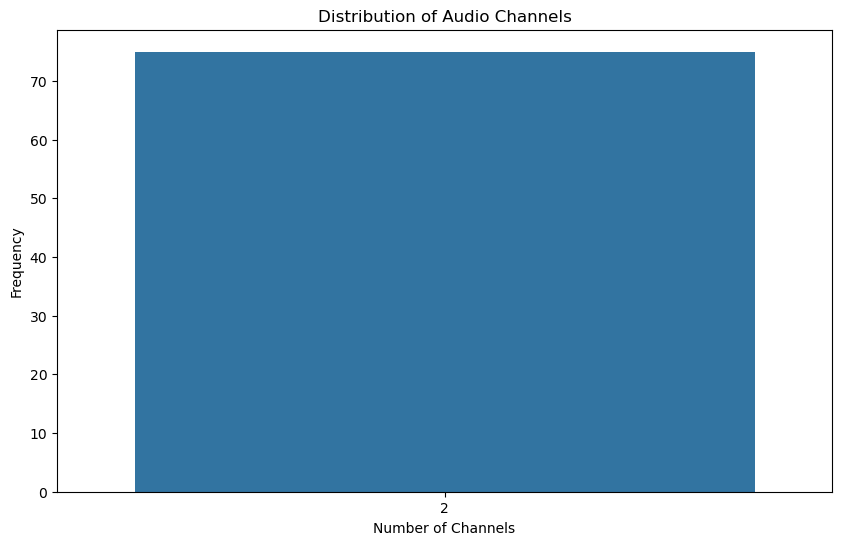

In [10]:

plt.figure(figsize=(10, 6))
sns.countplot(x=channels)
plt.title('Distribution of Audio Channels')
plt.xlabel('Number of Channels')
plt.ylabel('Frequency')
plt.show()




## Plot frame rates

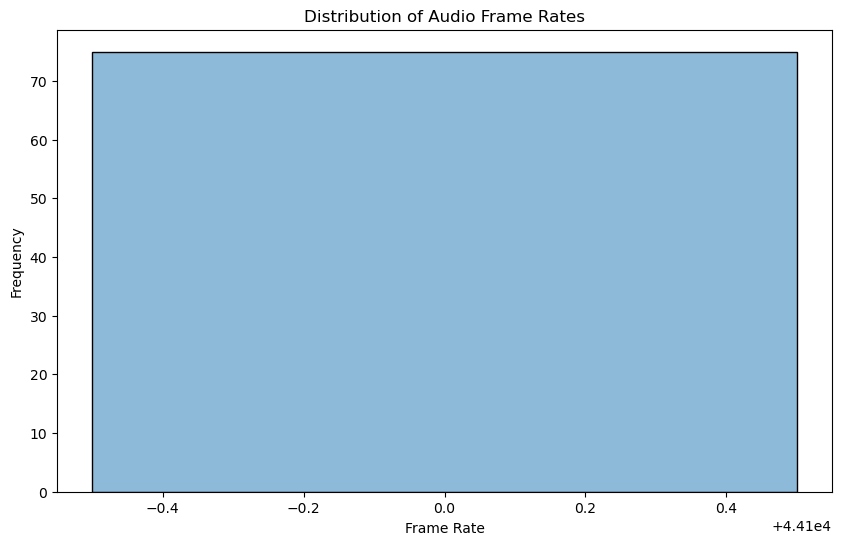

In [11]:
# Plot frame rates
plt.figure(figsize=(10, 6))
sns.histplot(frame_rates, kde=True)
plt.title('Distribution of Audio Frame Rates')
plt.xlabel('Frame Rate')
plt.ylabel('Frequency')
plt.show()



## Plot sample widths

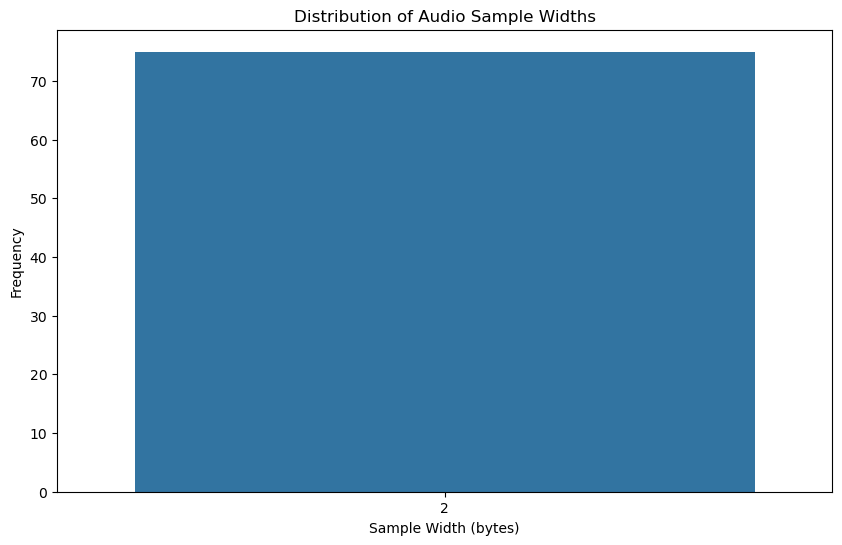

In [12]:

plt.figure(figsize=(10, 6))
sns.countplot(x=sample_widths)
plt.title('Distribution of Audio Sample Widths')
plt.xlabel('Sample Width (bytes)')
plt.ylabel('Frequency')
plt.show()

## Loudness

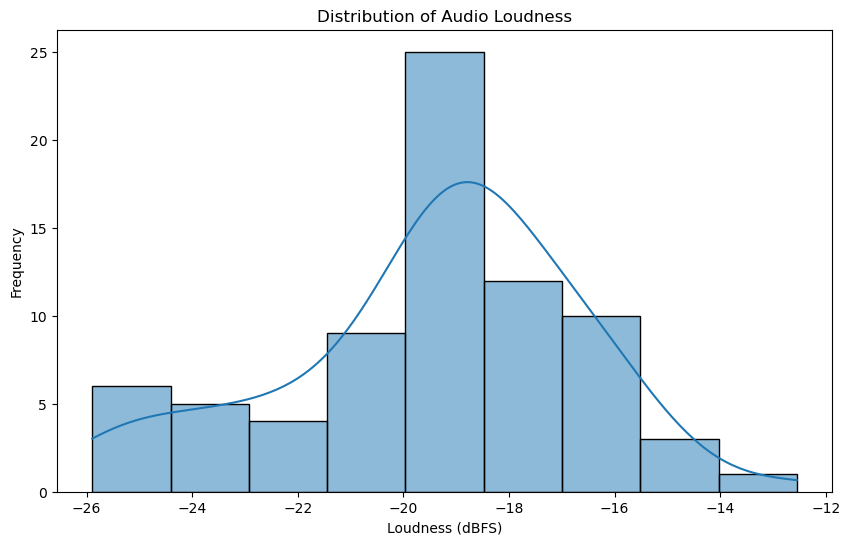

In [13]:
# Example: Calculate loudness (simplified approach)
loudness = []
for audio in audio_files.values():
    loudness.append(audio.dBFS)

# Plot loudness distribution
plt.figure(figsize=(10, 6))
sns.histplot(loudness, kde=True)
plt.title('Distribution of Audio Loudness')
plt.xlabel('Loudness (dBFS)')
plt.ylabel('Frequency')
plt.show()


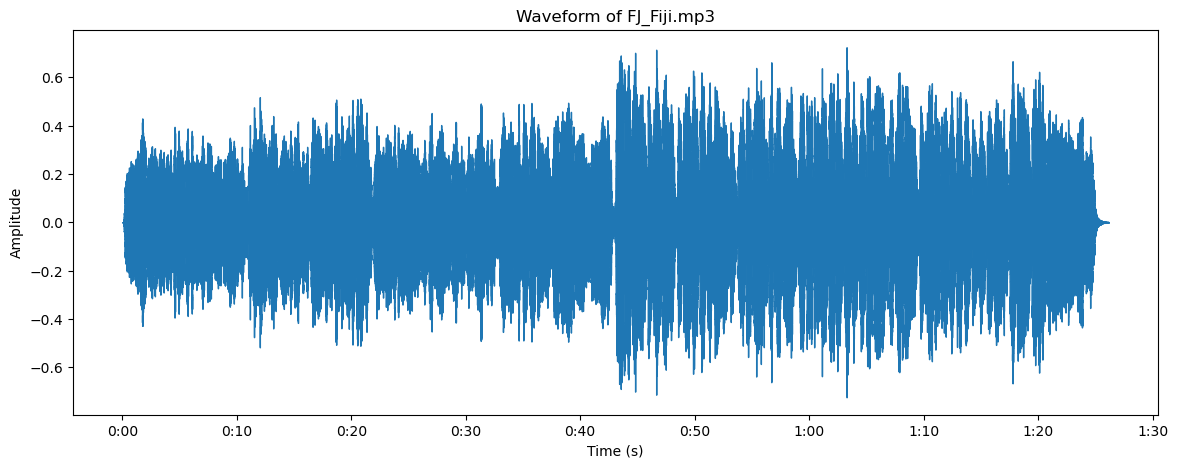

In [25]:
# %% Cell 1: Load and Plot Waveform of a Single MP3 File
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt

# Absolute path to a sample audio file (update if needed)
sample_file = "../A_DataCollection/mp3/FJ_Fiji.mp3"


from pydub import AudioSegment
AudioSegment.from_mp3(sample_file).export("temp.wav", format="wav")
y, sr = librosa.load("temp.wav")


plt.figure(figsize=(14, 5))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform of FJ_Fiji.mp3")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()


## Mel-Spectrogram Analysis

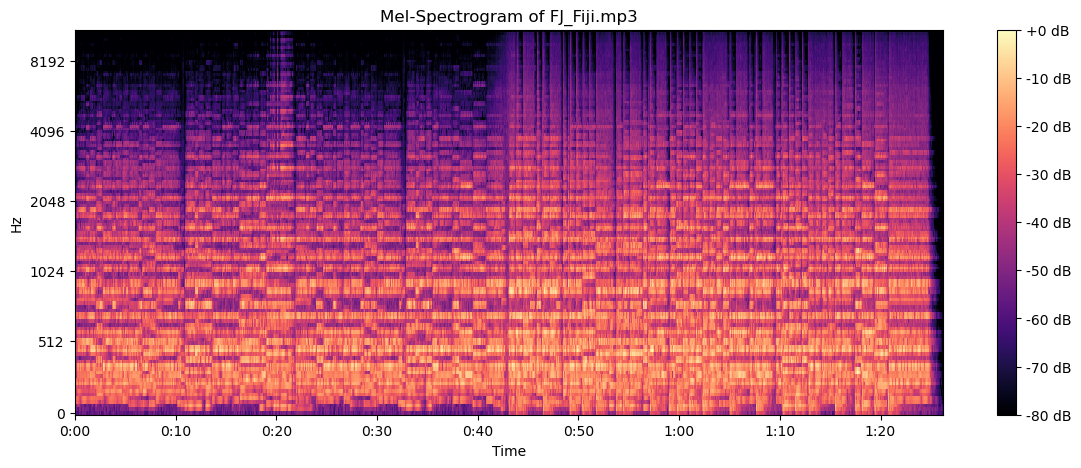

In [26]:
import numpy as np
import librosa.display

# Using the sample audio file loaded in Cell 1 (y, sr)
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
log_S = librosa.power_to_db(S, ref=np.max)

plt.figure(figsize=(14, 5))
librosa.display.specshow(log_S, sr=sr, x_axis='time', y_axis='mel')
plt.title("Mel-Spectrogram of FJ_Fiji.mp3")
plt.colorbar(format='%+2.0f dB')
plt.show()

## Beat Tracking and Tempo Estimation

C:\Users\priya\AppData\Local\Temp\ipykernel_21408\419628199.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"Estimated tempo: {float(tempo):.2f} BPM")


Estimated tempo: 92.29 BPM


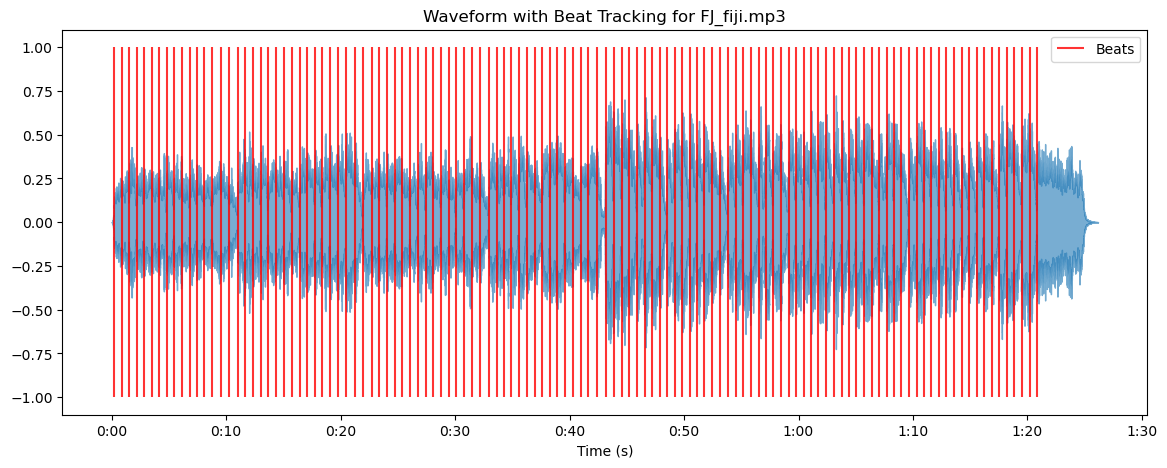

In [27]:
# %% Cell 3: Beat Tracking and Tempo Estimation
import librosa.display

# Compute tempo and beat frames for the sample file
tempo, beats = librosa.beat.beat_track(y=y, sr=sr)
print(f"Estimated tempo: {float(tempo):.2f} BPM")

# Convert beat frames to time
beat_times = librosa.frames_to_time(beats, sr=sr)

plt.figure(figsize=(14, 5))
librosa.display.waveshow(y, sr=sr, alpha=0.6)
plt.vlines(beat_times, -1, 1, color='r', alpha=0.8, label='Beats')
plt.title("Waveform with Beat Tracking for FJ_fiji.mp3")
plt.xlabel("Time (s)")
plt.legend()
plt.show()


## Batch Processing of Audio Files for Duration and Tempo

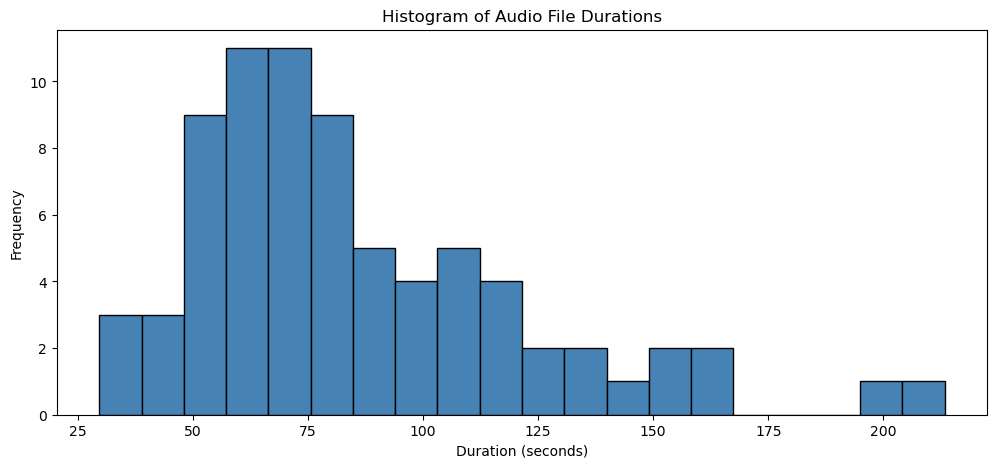

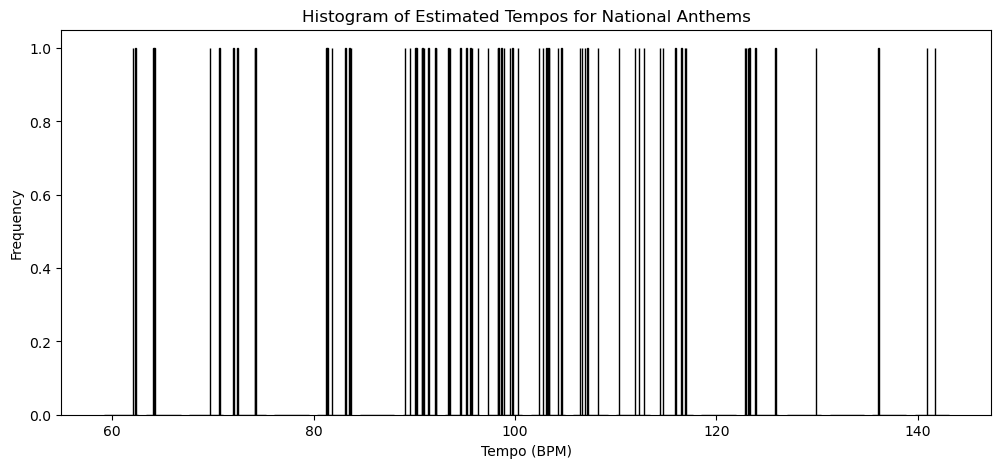

In [29]:
# %% Cell 4: Batch Processing of Audio Files for Duration and Tempo
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt

# Absolute path to the directory containing MP3 files
audio_dir = "../A_DataCollection/mp3"
durations = []
tempos = []
file_names = []

# Loop through all MP3 files in the directory
for file in os.listdir(audio_dir):
    if file.lower().endswith(".mp3"):
        file_path = os.path.join(audio_dir, file)
        try:
            from pydub import AudioSegment
            AudioSegment.from_mp3(file_path).export("temp.wav", format="wav")
            y, sr = librosa.load("temp.wav")
            duration = librosa.get_duration(y=y, sr=sr)
            durations.append(duration)
            tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
            tempos.append(tempo)
            file_names.append(file)
        except Exception as e:
            print(f"Error processing {file}: {e}")

# Plot histogram of durations
plt.figure(figsize=(12, 5))
plt.hist(durations, bins=20, edgecolor='black', color='steelblue')
plt.xlabel("Duration (seconds)")
plt.ylabel("Frequency")
plt.title("Histogram of Audio File Durations")
plt.show()

# Plot histogram of tempos
plt.figure(figsize=(12, 5))
plt.hist(tempos, bins=20, edgecolor='black')
plt.xlabel("Tempo (BPM)")
plt.ylabel("Frequency")
plt.title("Histogram of Estimated Tempos for National Anthems")
plt.show()


## MFCCs and Spectral Centroid Analysis for a Sample File

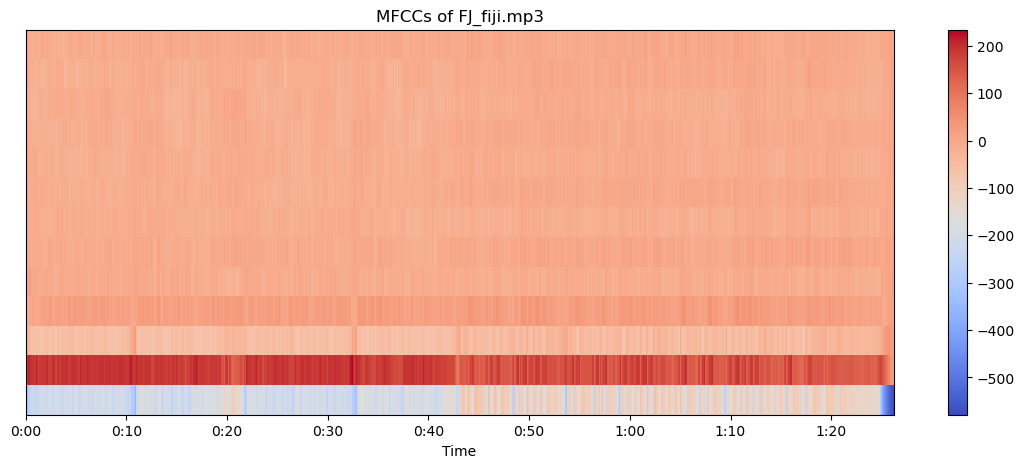

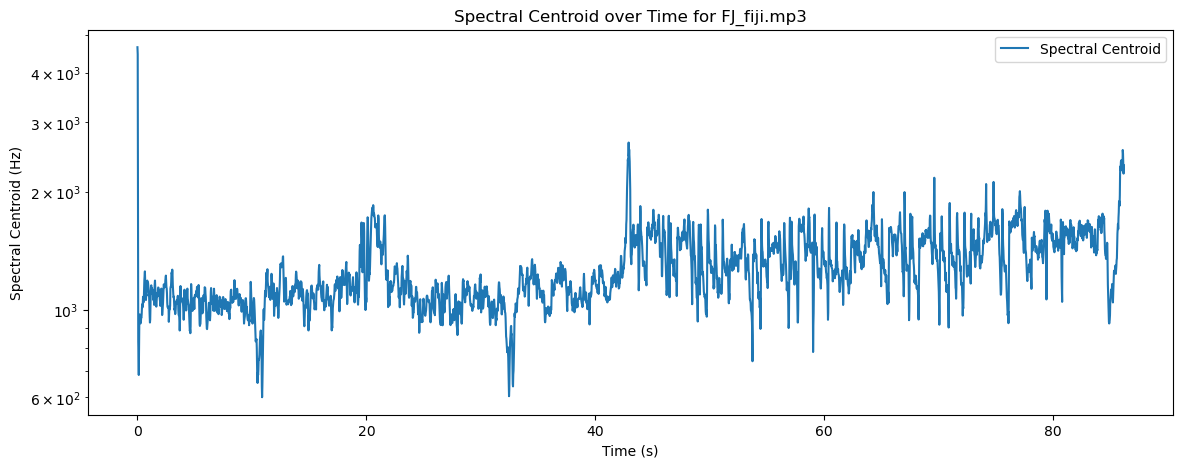

In [31]:
AudioSegment.from_mp3(sample_file).export("temp.wav", format="wav")
y, sr = librosa.load("temp.wav")

# Extract MFCCs
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
plt.figure(figsize=(14, 5))
librosa.display.specshow(mfccs, sr=sr, x_axis='time')
plt.colorbar()
plt.title("MFCCs of FJ_fiji.mp3")
plt.show()

# Compute spectral centroid
spectral_centroids = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
frames = range(len(spectral_centroids))
t = librosa.frames_to_time(frames, sr=sr)

plt.figure(figsize=(14, 5))
plt.semilogy(t, spectral_centroids, label='Spectral Centroid')
plt.xlabel("Time (s)")
plt.ylabel("Spectral Centroid (Hz)")
plt.title("Spectral Centroid over Time for FJ_fiji.mp3")
plt.legend()
plt.show()

## 